# 01 — Exploratory Data Analysis (EDA)
**Judul**: Klasifikasi Citra Bencana Alam Menggunakan MobileNetV2 Berbasis Deep Learning  
**Dataset**: Comprehensive Disaster Dataset (CDD) — Kaggle

---
### Roadmap
```
Dataset → EDA → Preprocessing → Augmentation → Split → Transfer Learning → Training
       → Fine-Tuning → Evaluation → Confusion Matrix → Classification Report
       → Grad-CAM → Prediction → Analisis → Kesimpulan
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter

from src.config import RAW_DIR, CLASS_MAPPING, CLASSES, IMAGE_SIZE
from src.dataset import scan_raw_dataset
from src.utils import print_class_distribution

sns.set_theme(style='whitegrid')
print('Setup OK')

✅ Config loaded successfully!
📁 RAW_DIR: C:\Users\ACER\Documents\ANALIS CITRA.py\dataset\raw\Comprehensive Disaster Dataset(CDD)
📁 TRAIN_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\train
📁 VAL_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\val
📁 TEST_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\test
📊 Classes: ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']
📐 Input Shape: (224, 224, 3)
🔄 FREEZE_EPOCHS: 10
🔄 FINETUNE_EPOCHS: 10
Setup OK


## 1. Informasi Dataset

In [2]:
# Scan raw dataset dan hitung per label
label_paths = scan_raw_dataset()
dist = {k: len(v) for k, v in label_paths.items()}
print_class_distribution(dist, 'Distribusi Raw Dataset CDD')

df = pd.DataFrame([
    {'Kelas': k, 'Jumlah': v, 'Persentase (%)': round(v/sum(dist.values())*100, 2)}
    for k, v in sorted(dist.items())
])
df.loc[len(df)] = ['TOTAL', sum(dist.values()), 100.0]
df

[SCAN] Damaged_Infrastructure              → Damaged_Infrastructure    (1454 gambar)
[SCAN] Fire_Disaster                       → Fire_Disaster             (933 gambar)
[SCAN] Human_Damage                        → Human_Damage              (241 gambar)
[SCAN] Land_Disaster                       → Land_Disaster             (657 gambar)
[SCAN] Non_Damage                          → Non_Damage                (9237 gambar)
[SCAN] Water_Disaster                      → Water_Disaster            (1035 gambar)

  Distribusi Raw Dataset CDD
  Damaged_Infrastructure  1454  ███
  Fire_Disaster          933  ██
  Human_Damage           241  
  Land_Disaster          657  █
  Non_Damage            9237  ████████████████████
  Water_Disaster        1035  ██
  TOTAL                13557



,Kelas,Jumlah,Persentase (%)
0,Damaged_Infrastructure,1454,10.73
1,Fire_Disaster,933,6.88
2,Human_Damage,241,1.78
3,Land_Disaster,657,4.85
4,Non_Damage,9237,68.13
5,Water_Disaster,1035,7.63
6,TOTAL,13557,100.00


## 2. Visualisasi Distribusi Kelas

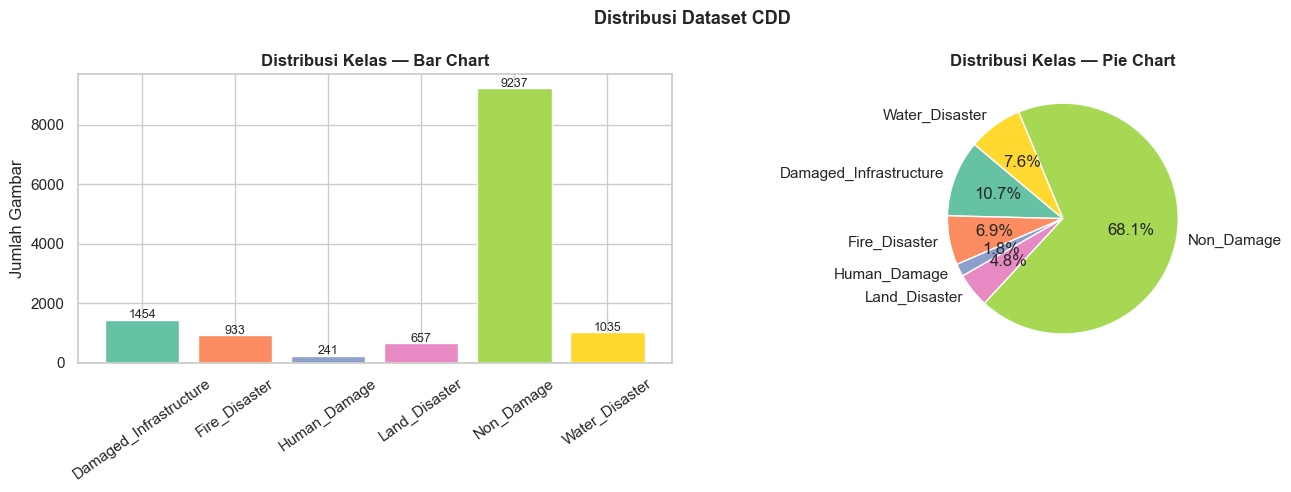

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cls_names = list(dist.keys())
cls_count = list(dist.values())
colors = sns.color_palette('Set2', len(cls_names))

bars = ax1.bar(cls_names, cls_count, color=colors, edgecolor='white')
ax1.set_title('Distribusi Kelas — Bar Chart', fontweight='bold')
ax1.set_ylabel('Jumlah Gambar')
ax1.tick_params(axis='x', rotation=35)
for bar, cnt in zip(bars, cls_count):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             str(cnt), ha='center', fontsize=9)

# Pie chart
ax2.pie(cls_count, labels=cls_names, autopct='%1.1f%%',
        colors=colors, startangle=140)
ax2.set_title('Distribusi Kelas — Pie Chart', fontweight='bold')

plt.suptitle('Distribusi Dataset CDD', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../results/eda', exist_ok=True)
plt.savefig('../results/eda/class_distribution_raw.png', dpi=150)
plt.show()

## 3. Sample Gambar per Kelas

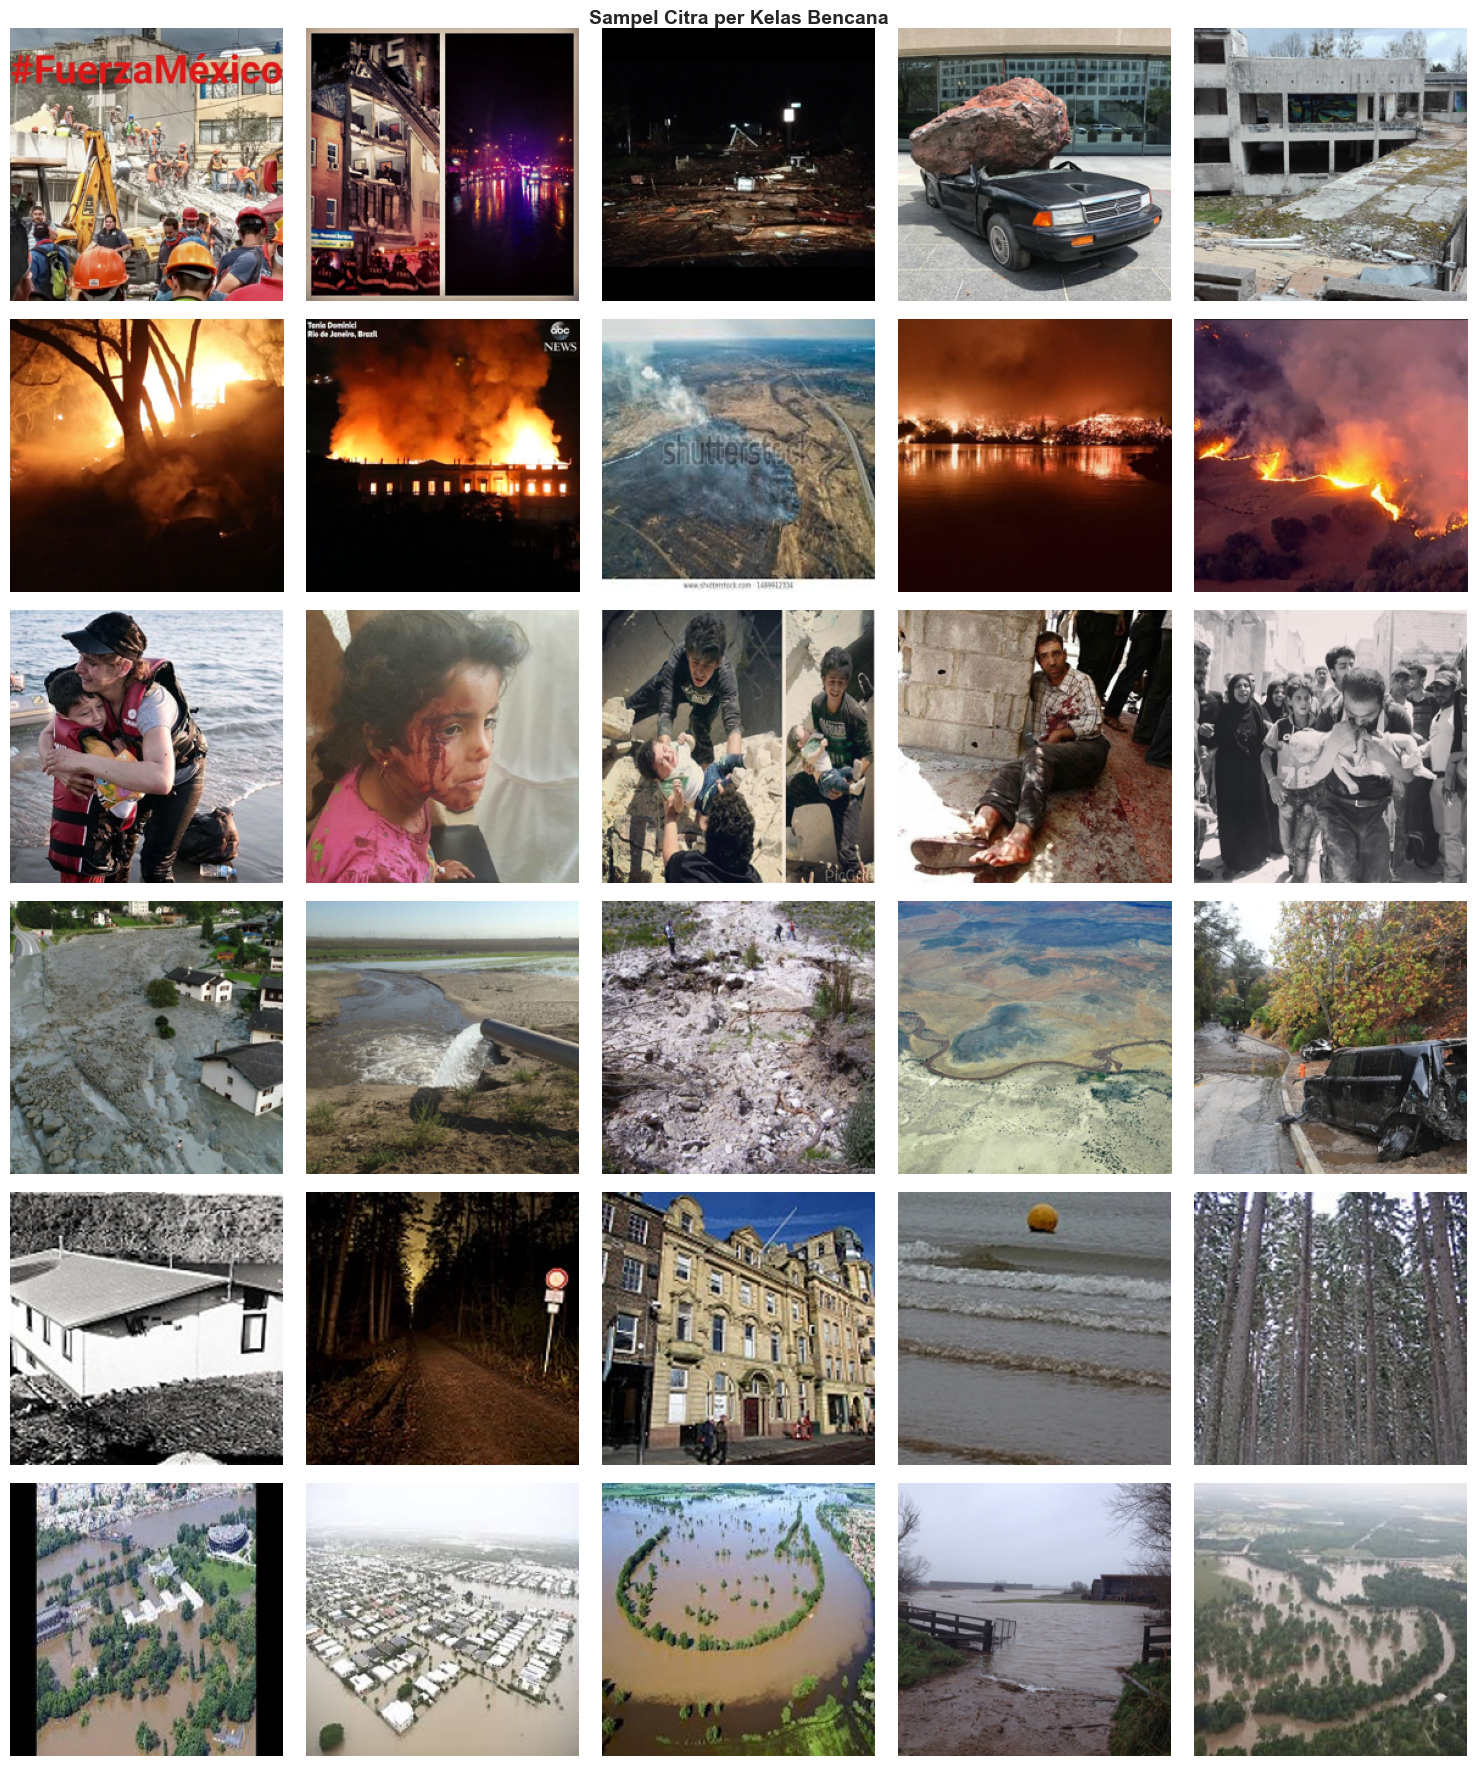

In [4]:
import random
n_show = 5
fig, axes = plt.subplots(len(label_paths), n_show,
                         figsize=(n_show*3, len(label_paths)*3))

for r, (cls, paths) in enumerate(sorted(label_paths.items())):
    samples = random.sample(paths, min(n_show, len(paths)))
    for c, p in enumerate(samples):
        img = Image.open(p).convert('RGB').resize(IMAGE_SIZE)
        axes[r, c].imshow(img)
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(cls, fontweight='bold', rotation=0,
                          labelpad=70, va='center', fontsize=11)

plt.suptitle('Sampel Citra per Kelas Bencana', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Statistik Dimensi Gambar

Width  — min:150, max:1080, mean:308
Height — min:113, max:1080, mean:286


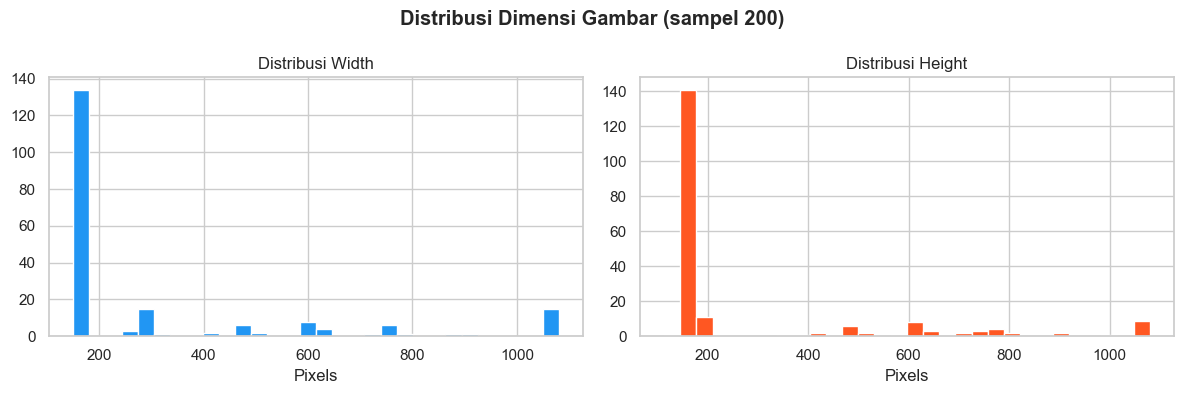

In [5]:
# Cek variasi ukuran gambar (sampel 200 gambar)
all_paths = [p for paths in label_paths.values() for p in paths]
sample_paths = random.sample(all_paths, min(200, len(all_paths)))

widths, heights = [], []
for p in sample_paths:
    try:
        with Image.open(p) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        pass

print(f'Width  — min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}')
print(f'Height — min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='#2196F3', edgecolor='white')
axes[0].set_title('Distribusi Width'); axes[0].set_xlabel('Pixels')
axes[1].hist(heights, bins=30, color='#FF5722', edgecolor='white')
axes[1].set_title('Distribusi Height'); axes[1].set_xlabel('Pixels')
plt.suptitle('Distribusi Dimensi Gambar (sampel 200)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda/image_dimensions.png', dpi=150)
plt.show()

## 5. Analisis Imbalance Dataset

Dataset CDD **tidak seimbang** — perlu diperhatikan saat training (class_weight atau oversampling).

In [6]:
total = sum(dist.values())
imbalance_ratio = max(dist.values()) / min(dist.values())
print(f'Imbalance Ratio (max/min): {imbalance_ratio:.2f}x')
print(f'Kelas terbesar: {max(dist, key=dist.get)} ({max(dist.values())} gambar)')
print(f'Kelas terkecil: {min(dist, key=dist.get)} ({min(dist.values())} gambar)')

# Class weight untuk mengatasi imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels_flat = []
for i, (cls, paths) in enumerate(sorted(label_paths.items())):
    labels_flat.extend([i] * len(paths))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_flat),
    y=labels_flat
)
cls_names_sorted = sorted(label_paths.keys())
print('\nClass Weights (untuk training):')
for cls, w in zip(cls_names_sorted, class_weights):
    print(f'  {cls:<15}: {w:.4f}')

Imbalance Ratio (max/min): 38.33x
Kelas terbesar: Non_Damage (9237 gambar)
Kelas terkecil: Human_Damage (241 gambar)

Class Weights (untuk training):
  Damaged_Infrastructure: 1.5540
  Fire_Disaster  : 2.4218
  Human_Damage   : 9.3755
  Land_Disaster  : 3.4391
  Non_Damage     : 0.2446
  Water_Disaster : 2.1831
